<a href="https://colab.research.google.com/github/alyssaplayer/BU_OMDS_APlayerRepo/blob/main/DX799_Capstone_USRecords_FINALVERSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/alyssaplayer/BU_OMDS_APlayerRepo/blob/main/Capstone/DX799_Capstone_USRecords_(ECommerce).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project — Summer Semester OMDS 2026

## United States E-Commerce Records (2020)

This notebook analyses the US E-Commerce Records (2020) dataset sourced from Kaggle (Ahmad, 2020). The dataset contains approximately 3,000 rows covering sales transactions across product categories, US regions, customer segments, and order dates.

The goal for this analysis is to identify key drivers for Profit at the order level, hoping to provide actionable insights of e-commerce retailers seeking to optimise regional inventory, refine marketing strategy, and anticipate demand shifts stemming from the 2020 COVID1-9 pandemic on US online purchasing behaviour.

###Key Stakeholders
The key stakeholders for this project are regional sales and operation managers, marketing demand analytics teams, supply chain leaders, and third-party sellers.

**Dataset features:**
Order ID,
Order Date,
Ship Mode,
Customer ID/Name,
Segment,
Country,
City,
State,
Postal Code,
Region,
Product ID,
Category,
Sub-Category,
Product Name,
Sales,
Quantity,
Discount,
Profit.

# 1. Load Required Libraries

In [ ]:
#pip install pandas matplotlib seaborn numpy kagglehub scikit-learn


In [1]:
import kagglehub
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# 2. Load Data

In [2]:
# U.S. E-Commerce Records (2020)
# Source: https://www.kaggle.com/datasets/ammaraahmad/us-ecommerce-record-2020

path = kagglehub.dataset_download("ammaraahmad/us-ecommerce-record-2020")
csv_files = glob.glob(os.path.join(path, '*.csv'))

if csv_files:
    df_raw = pd.read_csv(csv_files[0], encoding='latin1')
    print(f"Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
    display(df_raw.head())
else:
    print("No CSV files found.")

100%|██████████| 160k/160k [00:00<00:00, 23.7MB/s]

Extracting files...


Dataset loaded: 3,312 rows × 19 columns


,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815


# 3. Exploratory Data Analysis (EDA)



In [3]:
# Shape, dtypes, and null counts
print("Shape:", df_raw.shape)
print("\nColumn dtypes:")
print(df_raw.dtypes)
print("\nMissing values per column:")
print(df_raw.isnull().sum())

Shape: (3312, 19)

Column dtypes:
Order Date       object
Row ID            int64
Order ID         object
Ship Mode        object
Customer ID      object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Product ID       object
Category         object
Sub-Category     object
Product Name     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Missing values per column:
Order Date      0
Row ID          0
Order ID        0
Ship Mode       0
Customer ID     0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [5]:
# Summary statistics
display(df_raw.describe())

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,3312.000000,3312.000000,3312.000000,3312.000000,3312.000000,3312.000000
mean,5087.107488,56186.515097,221.381418,3.766908,0.156467,28.212340
std,2817.482266,31980.375516,585.257531,2.221776,0.207429,241.864342
min,13.000000,1841.000000,0.444000,1.000000,0.000000,-3839.990400
25%,2655.750000,27978.750000,17.018000,2.000000,0.000000,1.763200
50%,5183.500000,60472.500000,53.810000,3.000000,0.200000,8.296800
75%,7498.250000,90032.000000,205.105700,5.000000,0.200000,28.315125
max,9994.000000,99301.000000,13999.960000,14.000000,0.800000,6719.980800


In [6]:
# Categorical value counts
for col in ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']:
    print(f"\n{col}:")
    print(df_raw[col].value_counts())


Category:
Category
Office Supplies    2002
Furniture           686
Technology          624
Name: count, dtype: int64

Sub-Category:
Sub-Category
Binders        500
Paper          459
Furnishings    316
Phones         294
Storage        288
Art            282
Accessories    275
Chairs         190
Appliances     165
Labels         114
Tables         104
Bookcases       76
Envelopes       71
Fasteners       64
Supplies        59
Machines        33
Copiers         22
Name: count, dtype: int64

Segment:
Segment
Consumer       1668
Corporate       980
Home Office     664
Name: count, dtype: int64

Region:
Region
West       1095
East        921
Central     778
South       518
Name: count, dtype: int64

Ship Mode:
Ship Mode
Standard Class    1897
Second Class       657
First Class        572
Same Day           186
Name: count, dtype: int64


## EDA Visualisations

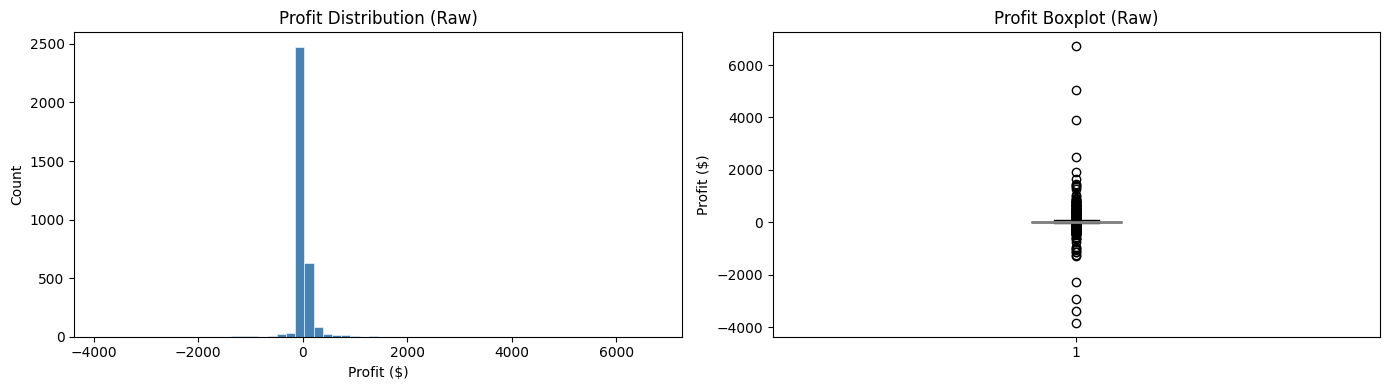

Profit skewness: 8.217


In [7]:
# Distribution of profit
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw['Profit'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Profit Distribution (Raw)')
axes[0].set_xlabel('Profit ($)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df_raw['Profit'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='grey', linewidth=2))
axes[1].set_title('Profit Boxplot (Raw)')
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.show()
print(f"Profit skewness: {df_raw['Profit'].skew():.3f}")

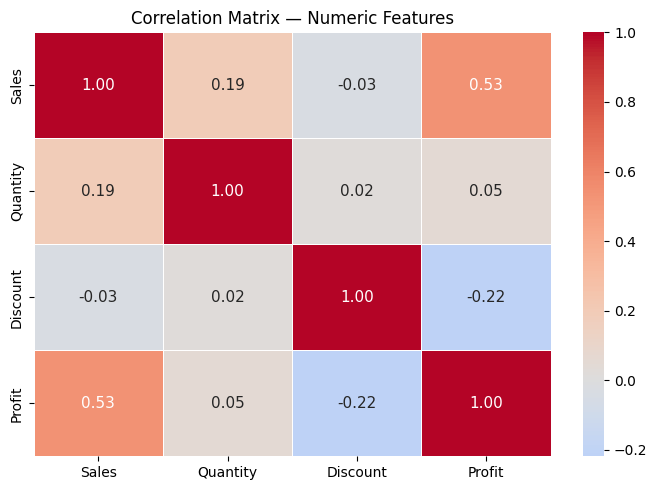

In [8]:
#Correlation Matrix of Numeric Features
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
corr_matrix = df_raw[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 11})
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()

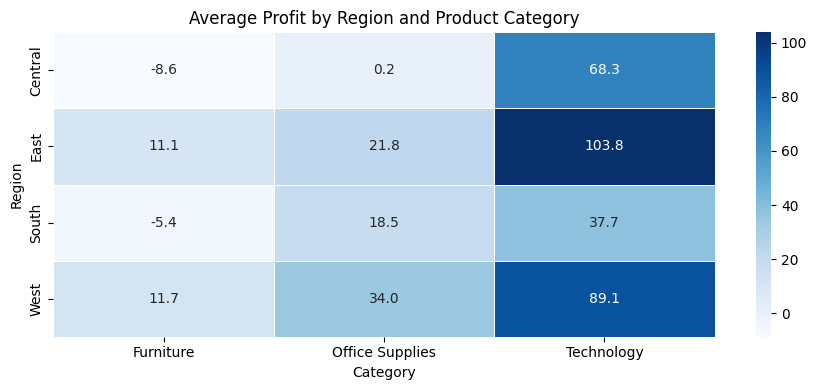

In [10]:
# Mean Profit by Category and Region (Heatmap)
pivot = df_raw.pivot_table(values='Profit', index='Region', columns='Category', aggfunc='mean')

plt.figure(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5,
            annot_kws={'size': 10})
plt.title('Average Profit by Region and Product Category')
plt.tight_layout()
plt.show()

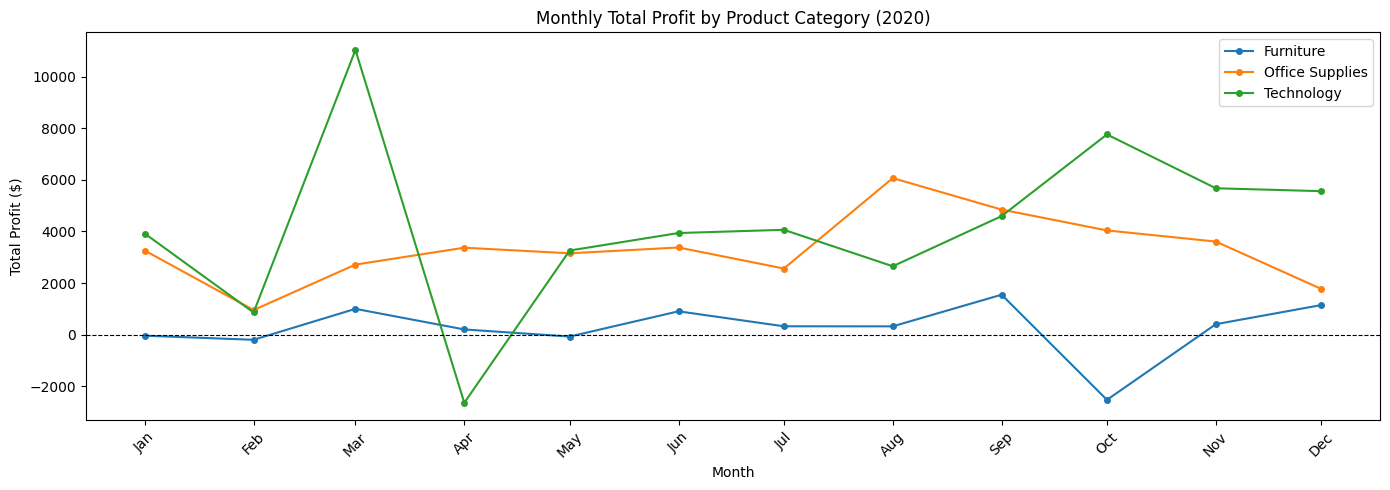

In [11]:
# Monthly Profit Trend by Category
df_plot = df_raw.copy()
df_plot['Order Date'] = pd.to_datetime(df_plot['Order Date'], format='%d-%m-%y')
df_plot['YearMonth'] = df_plot['Order Date'].dt.to_period('M').dt.to_timestamp()

monthly_cat = df_plot.groupby(['YearMonth', 'Category'])['Profit'].sum().reset_index()

plt.figure(figsize=(14, 5))
for cat, grp in monthly_cat.groupby('Category'):
    plt.plot(grp['YearMonth'], grp['Profit'], marker='o', markersize=4, label=cat)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Monthly Total Profit by Product Category (2020)')
plt.xlabel('Month')
plt.ylabel('Total Profit ($)')
plt.legend()
plt.xticks(ticks=monthly_cat['YearMonth'].unique(),
           labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
           rotation=45)
plt.tight_layout()
plt.show()

# 4. Feature Engineering

Certain features were engineered to support format expectations from supervised and unsupervised modelling.

In [12]:
df = df_raw.copy()

# Parse datatypes
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%y')
df['Postal Code'] = df['Postal Code'].astype(str)

# Date signals
df['Order_Year']      = df['Order Date'].dt.year
df['Order_Month']     = df['Order Date'].dt.month
df['Order_DayOfWeek'] = df['Order Date'].dt.dayofweek   # Mon=0, Sun=6
df['Is_Weekend']      = (df['Order_DayOfWeek'] >= 5).astype(int)

# Clip profit outliers, to help distribution
lower = df['Profit'].quantile(0.01)
upper = df['Profit'].quantile(0.99)
df['Profit_clipped'] = df['Profit'].clip(lower, upper)
print(f"Profit clipped to [{lower:.2f}, {upper:.2f}]")

# Binary target: 1 = above-median profit, 0 = below, for classification models
profit_median = df['Profit_clipped'].median()
df['High_Profit'] = (df['Profit_clipped'] > profit_median).astype(int)
print(f"Median profit (clipped): ${profit_median:.2f}")
print(f"High_Profit class balance:\n{df['High_Profit'].value_counts()}")

Profit clipped to [-335.87, 608.86]
Median profit (clipped): $8.30
High_Profit class balance:
High_Profit
1    1656
0    1656
Name: count, dtype: int64


In [13]:
# One hot encode categorical variables
cat_features = ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']
df_encoded = pd.get_dummies(df, columns=cat_features, drop_first=True)

# Regression feature set (numeric + encoded categoricals + date signals)
feature_cols = (
    ['Sales', 'Quantity', 'Discount',
     'Order_Month', 'Order_DayOfWeek', 'Is_Weekend']
    + [c for c in df_encoded.columns
       if any(c.startswith(p + '_') for p in cat_features)]
)

# Remove any booleans, int for sklearn compatibility
df_encoded[feature_cols] = df_encoded[feature_cols].astype(float)

print(f"Feature set: {len(feature_cols)} columns")
print(feature_cols)

Feature set: 32 columns
['Sales', 'Quantity', 'Discount', 'Order_Month', 'Order_DayOfWeek', 'Is_Weekend', 'Category_Office Supplies', 'Category_Technology', 'Sub-Category_Appliances', 'Sub-Category_Art', 'Sub-Category_Binders', 'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers', 'Sub-Category_Envelopes', 'Sub-Category_Fasteners', 'Sub-Category_Furnishings', 'Sub-Category_Labels', 'Sub-Category_Machines', 'Sub-Category_Paper', 'Sub-Category_Phones', 'Sub-Category_Storage', 'Sub-Category_Supplies', 'Sub-Category_Tables', 'Segment_Corporate', 'Segment_Home Office', 'Region_East', 'Region_South', 'Region_West', 'Ship Mode_Same Day', 'Ship Mode_Second Class', 'Ship Mode_Standard Class']


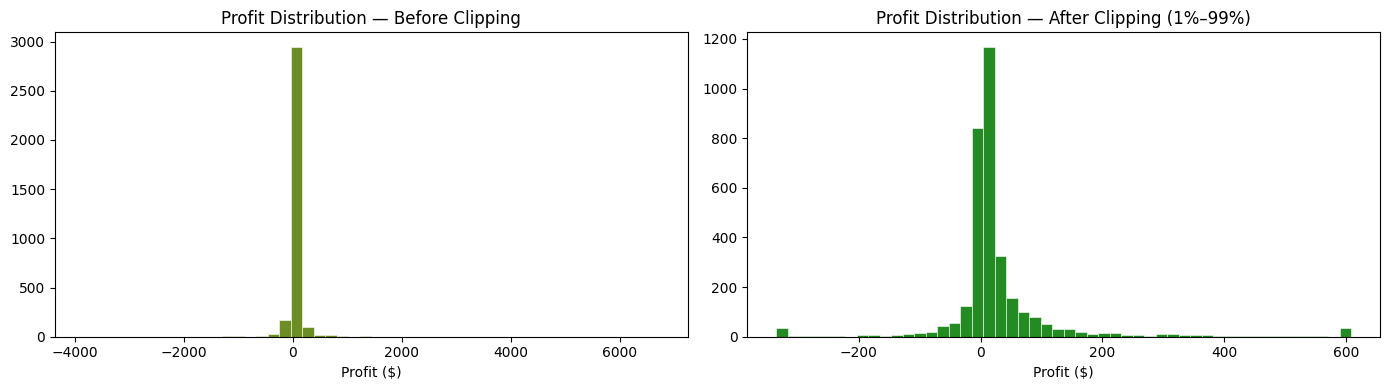

In [14]:
# Visualise profit before and after clipping
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Profit'], bins=50, color='olivedrab', edgecolor='white', linewidth=0.4)
axes[0].set_title('Profit Distribution — Before Clipping')
axes[0].set_xlabel('Profit ($)')

axes[1].hist(df['Profit_clipped'], bins=50, color='forestgreen', edgecolor='white', linewidth=0.4)
axes[1].set_title('Profit Distribution — After Clipping (1%–99%)')
axes[1].set_xlabel('Profit ($)')

plt.tight_layout()
plt.show()

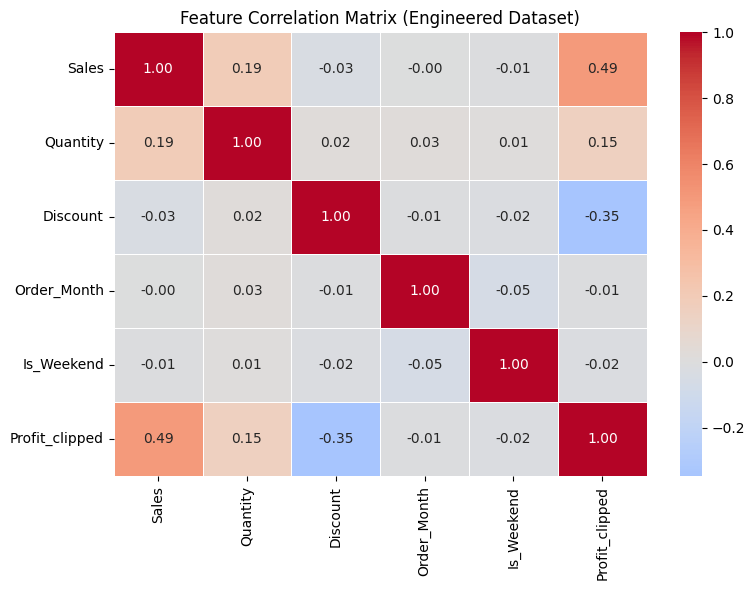

In [15]:
# Correlation Matrix
core_num = ['Sales', 'Quantity', 'Discount', 'Order_Month', 'Is_Weekend', 'Profit_clipped']
corr_fe = df_encoded[core_num].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_fe, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Feature Correlation Matrix (Engineered Dataset)')
plt.tight_layout()
plt.show()

In [16]:
# Train/Test split
from sklearn.model_selection import train_test_split

df_model = df_encoded.dropna(subset=feature_cols + ['Profit_clipped', 'High_Profit']).copy()

X = df_model[feature_cols]
y_reg   = df_model['Profit_clipped']   # continuous target
y_clf   = df_model['High_Profit']       # binary classification target

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42)

print(f"Modelling dataset: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"\nHigh_Profit class distribution (test):\n{y_test_clf.value_counts()}")

Modelling dataset: 3,312 rows × 32 features
Train: 2,649 | Test: 663

High_Profit class distribution (test):
High_Profit
1    363
0    300
Name: count, dtype: int64


# W1: Linear Regression

OLS is used to establish baseline performance.

**Target:** `Profit_clipped` (continuous)  
**Metrics:** R² and RMSE

In [17]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train_reg)
y_pred_lr = lr.predict(X_test)

r2_lr   = r2_score(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))

print(f"Linear Regression | R²: {r2_lr:.4f} | RMSE: ${rmse_lr:.2f}")

Linear Regression | R²: 0.3888 | RMSE: $91.21


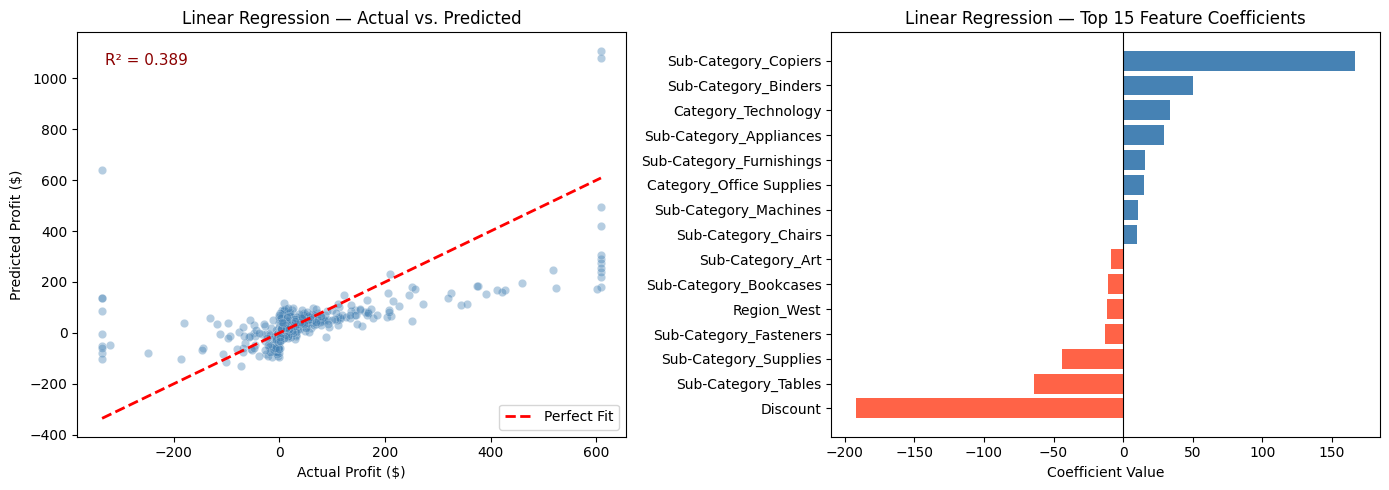

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_reg, y_pred_lr, alpha=0.4, color='steelblue',
                edgecolors='white', linewidth=0.3)
axes[0].plot([y_test_reg.min(), y_test_reg.max()],
             [y_test_reg.min(), y_test_reg.max()], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Profit ($)')
axes[0].set_ylabel('Predicted Profit ($)')
axes[0].set_title('Linear Regression — Actual vs. Predicted')
axes[0].legend()
axes[0].annotate(f'R² = {r2_lr:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=11, color='darkred')

# Feature coefficients (top 15 by absolute value)
coef_df = pd.Series(lr.coef_, index=feature_cols).reindex(
    pd.Series(lr.coef_, index=feature_cols).abs().nlargest(15).index)
coef_df = coef_df.sort_values(ascending=True)
axes[1].barh(coef_df.index, coef_df.values,
             color=['tomato' if v < 0 else 'steelblue' for v in coef_df.values])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Linear Regression — Top 15 Feature Coefficients')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

##W1 Summary

The linear regression model output an R^2 score of 0.389, which explains approximately 39% of variance in order-level profit. Discount has the largest negative coefficient confirming that discounting is the greatest driver of Profit loss, which makes sense from a mathematical persperctive.

Sub-categories, supplies and tables, also have negative coefficients. Sub-categories, copies, binders, and appliances, are the strongest profit boosting coefficients.

# W2: Regularised Regression — Lasso, Ridge, and Elastic Net


In [21]:
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV

alphas = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

# Lassso
lasso_cv = GridSearchCV(Lasso(max_iter=10000), {'alpha': alphas},
                        cv=5, scoring='r2', n_jobs=-1)
lasso_cv.fit(X_train, y_train_reg)
lasso_best = lasso_cv.best_estimator_
print(f"Lasso best alpha: {lasso_cv.best_params_['alpha']}")

# Ridge
ridge_cv = GridSearchCV(Ridge(), {'alpha': alphas},
                        cv=5, scoring='r2', n_jobs=-1)
ridge_cv.fit(X_train, y_train_reg)
ridge_best = ridge_cv.best_estimator_
print(f"Ridge best alpha: {ridge_cv.best_params_['alpha']}")

# Elastic Net
en_params = {'alpha': alphas, 'l1_ratio': [0.2, 0.5, 0.8]}
en_cv = GridSearchCV(ElasticNet(max_iter=10000), en_params,
                     cv=5, scoring='r2', n_jobs=-1)
en_cv.fit(X_train, y_train_reg)
en_best = en_cv.best_estimator_
print(f"ElasticNet best params: {en_cv.best_params_}")

Lasso best alpha: 0.1
Ridge best alpha: 5.0
ElasticNet best params: {'alpha': 0.01, 'l1_ratio': 0.8}


In [22]:
# Comparison table
results_w2 = {}
for name, m in [('Lasso', lasso_best), ('Ridge', ridge_best), ('ElasticNet', en_best)]:
    preds = m.predict(X_test)
    results_w2[name] = {
        'R²':  round(r2_score(y_test_reg, preds), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test_reg, preds)), 2),
        'MAE':  round(mean_absolute_error(y_test_reg, preds), 2)
    }
    print(f"{name:12s} | R²: {results_w2[name]['R²']:.4f} "
          f"| RMSE: ${results_w2[name]['RMSE']:.2f} "
          f"| MAE: ${results_w2[name]['MAE']:.2f}")

Lasso        | R²: 0.3916 | RMSE: $91.00 | MAE: $44.65
Ridge        | R²: 0.3872 | RMSE: $91.34 | MAE: $44.40
ElasticNet   | R²: 0.3871 | RMSE: $91.34 | MAE: $44.32


Lasso zeroed out 5 of 32 features


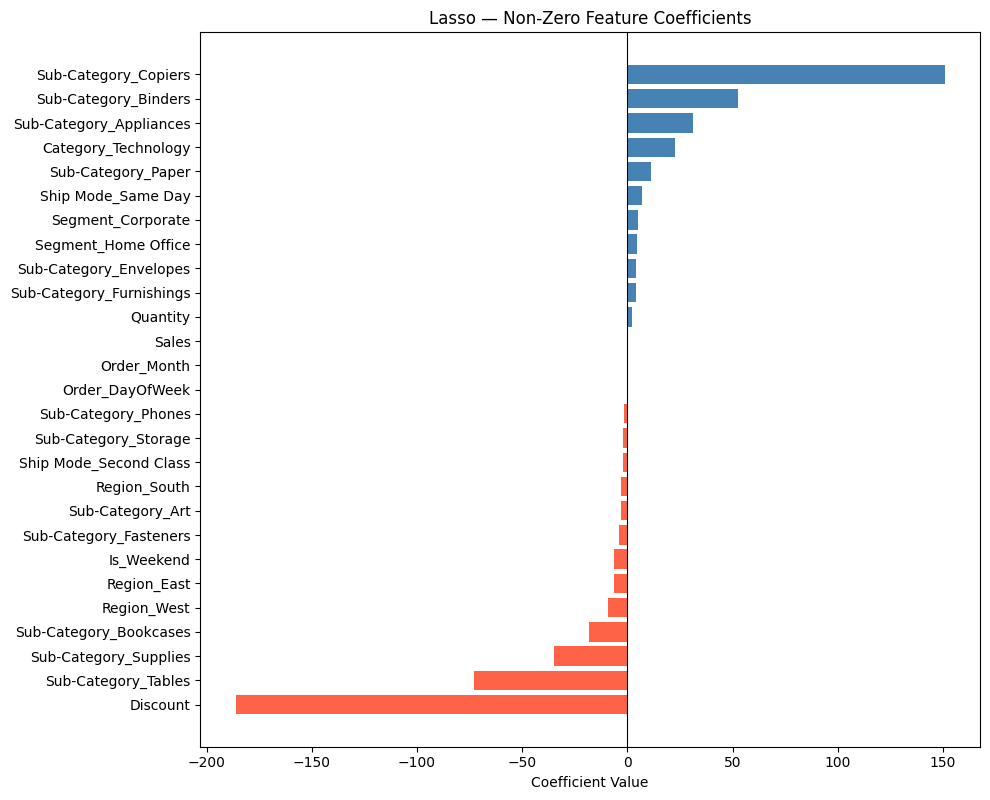

In [23]:
# --- Lasso coefficient path (features driven to zero) ---
lasso_coefs = pd.Series(lasso_best.coef_, index=feature_cols)
n_zero = (lasso_coefs == 0).sum()
print(f"Lasso zeroed out {n_zero} of {len(feature_cols)} features")

# Plot non-zero coefficients
nonzero = lasso_coefs[lasso_coefs != 0].sort_values()
plt.figure(figsize=(10, max(4, len(nonzero) * 0.3)))
plt.barh(nonzero.index, nonzero.values,
         color=['tomato' if v < 0 else 'steelblue' for v in nonzero.values])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Lasso — Non-Zero Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## W2 Summary

Lasso        
| R²: 0.3916 | RMSE: $91.00 | MAE: $44.65

Ridge       
 | R²: 0.3872 | RMSE: $91.34 | MAE: $44.40

ElasticNet   
| R²: 0.3871 | RMSE: $91.34 | MAE: $44.32

All three models performed very similarly, with Lasso outperforming the other two by a fraction. The features explain 39% of variance in Profit, which indicates that there are other missed features that drive Profit further.

# W3: Feature Selection, PCR, and PLSR

### Forward / Backward Stepwise Selection


### Principal Components Regression (PCR)


### Partial Least Squares Regression (PLSR)



In [24]:
# Standardise features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [27]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

# Forward Selection
forward_selector = SFS(lr, k_features='best', forward=True,
                       floating=False, scoring='r2', cv=5, n_jobs=-1)
forward_selector.fit(X_train, y_train_reg)
print(f"Forward Selection — best {len(forward_selector.k_feature_names_)} features:")
print(list(forward_selector.k_feature_names_))

# Backward Selection
backward_selector = SFS(lr, k_features='best', forward=False,
                        floating=False, scoring='r2', cv=5, n_jobs=-1)
backward_selector.fit(X_train, y_train_reg)
print(f"\nBackward Selection — best {len(backward_selector.k_feature_names_)} features:")
print(list(backward_selector.k_feature_names_))

Forward Selection — best 18 features:
['Sales', 'Quantity', 'Discount', 'Is_Weekend', 'Category_Office Supplies', 'Category_Technology', 'Sub-Category_Appliances', 'Sub-Category_Binders', 'Sub-Category_Bookcases', 'Sub-Category_Copiers', 'Sub-Category_Fasteners', 'Sub-Category_Paper', 'Sub-Category_Supplies', 'Sub-Category_Tables', 'Segment_Corporate', 'Segment_Home Office', 'Region_West', 'Ship Mode_Same Day']

Backward Selection — best 19 features:
['Sales', 'Quantity', 'Discount', 'Is_Weekend', 'Category_Office Supplies', 'Sub-Category_Appliances', 'Sub-Category_Binders', 'Sub-Category_Bookcases', 'Sub-Category_Chairs', 'Sub-Category_Copiers', 'Sub-Category_Fasteners', 'Sub-Category_Furnishings', 'Sub-Category_Paper', 'Sub-Category_Supplies', 'Sub-Category_Tables', 'Segment_Corporate', 'Segment_Home Office', 'Region_West', 'Ship Mode_Same Day']


In [29]:
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline

# Determine n_components for 90% explained variance
pca_full = PCA().fit(X_train_sc)
explained_variance_ratio_cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.where(explained_variance_ratio_cumsum >= 0.90)[0][0] + 1
print(f"Number of components explaining 90% variance: {n_components_90}")

# Principal Component Regression
# Using pre-scaled data (X_train_sc, X_test_sc) so StandardScaler is not needed in the pipeline
pcr_pipeline = Pipeline([
    ("pca",   PCA(n_components=n_components_90)),
    ("lr",    LinearRegression())
])
pcr_pipeline.fit(X_train_sc, y_train_reg)
pcr_preds = pcr_pipeline.predict(X_test_sc)
print(f"PCR  (n={n_components_90} components) | R²: {r2_score(y_test_reg, pcr_preds):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_reg, pcr_preds)):.4f}")

# Partial Least Squares Regression
# Using pre-scaled data (X_train_sc, X_test_sc)
plsr_model = PLSRegression(n_components=n_components_90)
plsr_model.fit(X_train_sc, y_train_reg)
plsr_preds = plsr_model.predict(X_test_sc).ravel()
print(f"PLSR (n={n_components_90} components) | R²: {r2_score(y_test_reg, plsr_preds):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test_reg, plsr_preds)):.4f}")

Number of components explaining 90% variance: 23
PCR  (n=23 components) | R²: 0.3206 | RMSE: 96.1673
PLSR (n=23 components) | R²: 0.3888 | RMSE: 91.2137


## W3 Summary

Both forward and backward selection converge on nearly the same feature. Forward selection picks 'Category_Technology', whereas backward selection retains 'Sub-category_chairs' and 'sub_category_furnishins'.

Consistency lies in predictors 'Sales', 'Quantity', 'Discount', and 'Is_Weekend', and sub-categories 'Region_West, 'Ship_Mode_SameDay'.

PCR and PLSR use 23 components to explain 90% of the variance, but PLSR (R^2 0.389, RMSE $91.21) outperforms PCR (R^2 0.321, RMSE $96.17.

This also matches Lasso and Ridge.

# W4: Logistic Regression with Feature Scaling


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)

# build ipeline: scale → logistic regression
log_reg_pipeline = Pipeline([
    ("scaler",   StandardScaler()),
    ("logistic", LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])
log_reg_pipeline.fit(X_train, y_train_clf)
y_pred_lr = log_reg_pipeline.predict(X_test)

print("Logistic Regression (Scaled) Results")
print("=" * 58)
print(classification_report(y_test_clf, y_pred_lr,
                             target_names=['Low Profit', 'High Profit']))
print(f"Overall Accuracy: {accuracy_score(y_test_clf, y_pred_lr):.4f}")

Logistic Regression (Scaled) Results
              precision    recall  f1-score   support

  Low Profit       0.75      0.77      0.76       300
 High Profit       0.81      0.79      0.80       363

    accuracy                           0.78       663
   macro avg       0.78      0.78      0.78       663
weighted avg       0.78      0.78      0.78       663

Overall Accuracy: 0.7798


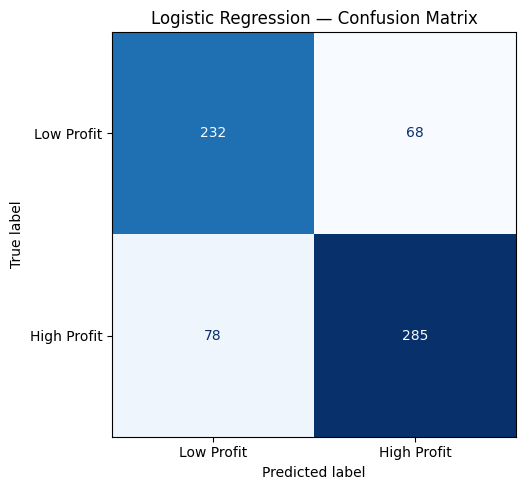

In [34]:
# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Profit', 'High Profit'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

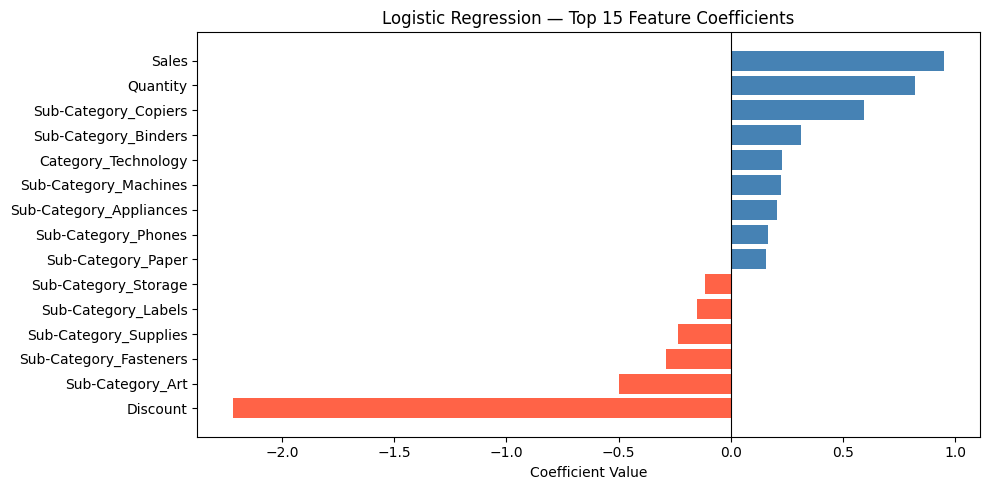

In [35]:
# Top feature coefficients from Logistic Regression
log_coef = pd.Series(log_best.coef_[0], index=feature_cols)
top_log = log_coef.abs().nlargest(15).index
log_coef_top = log_coef[top_log].sort_values()

plt.figure(figsize=(10, 5))
plt.barh(log_coef_top.index, log_coef_top.values,
         color=['tomato' if v < 0 else 'steelblue' for v in log_coef_top.values])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Top 15 Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

##W4 Summary

The logistic regression model achieves 78% accuracy in classifying orders as high or low profit.

The pattern of feature coefficients looks similar to the regression from earlier. Sales, quantity, sub-categories 'copiers', 'binders', 'machines', 'appliances', 'phones', and 'paper' are high indications of being classified as high profit. 'Discount' is again a strong negative coefficient of Profit with sub-categories 'art' and 'fasteners'.


The model performed minorly better on the high profit class F1: 0.8, than low profit F1 = 0.76.

# W5: Support Vector Machines (SVM)


In [36]:
from sklearn.svm import SVC

# GridSearch over kernel and C
svm_params = {
    'C':      [0.1, 1.0, 10.0],
    'kernel': ['linear', 'rbf'],
    'gamma':  ['scale']
}
svm_cv = GridSearchCV(
    SVC(random_state=42, probability=True),
    svm_params, cv=5, scoring='f1', n_jobs=-1
)
svm_cv.fit(X_train_sc, y_train_clf)
svm_best = svm_cv.best_estimator_
print(f"Best SVM params: {svm_cv.best_params_}")

y_pred_svm = svm_best.predict(X_test_sc)
print(f"\nAccuracy: {accuracy_score(y_test_clf, y_pred_svm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_svm, target_names=['Low Profit', 'High Profit']))

Best SVM params: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}

Accuracy: 0.7647

Classification Report:
              precision    recall  f1-score   support

  Low Profit       0.72      0.77      0.75       300
 High Profit       0.80      0.76      0.78       363

    accuracy                           0.76       663
   macro avg       0.76      0.77      0.76       663
weighted avg       0.77      0.76      0.77       663



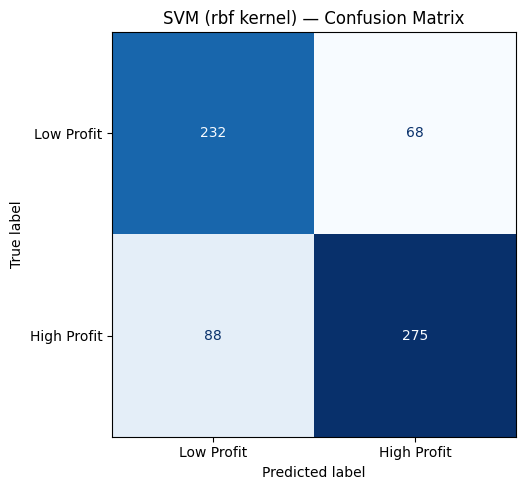

In [38]:
# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test_clf, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm,
                                  display_labels=['Low Profit', 'High Profit'])

fig, ax = plt.subplots(figsize=(6, 5))
disp_svm.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"SVM ({svm_best.kernel} kernel) — Confusion Matrix")
plt.tight_layout()
plt.show()

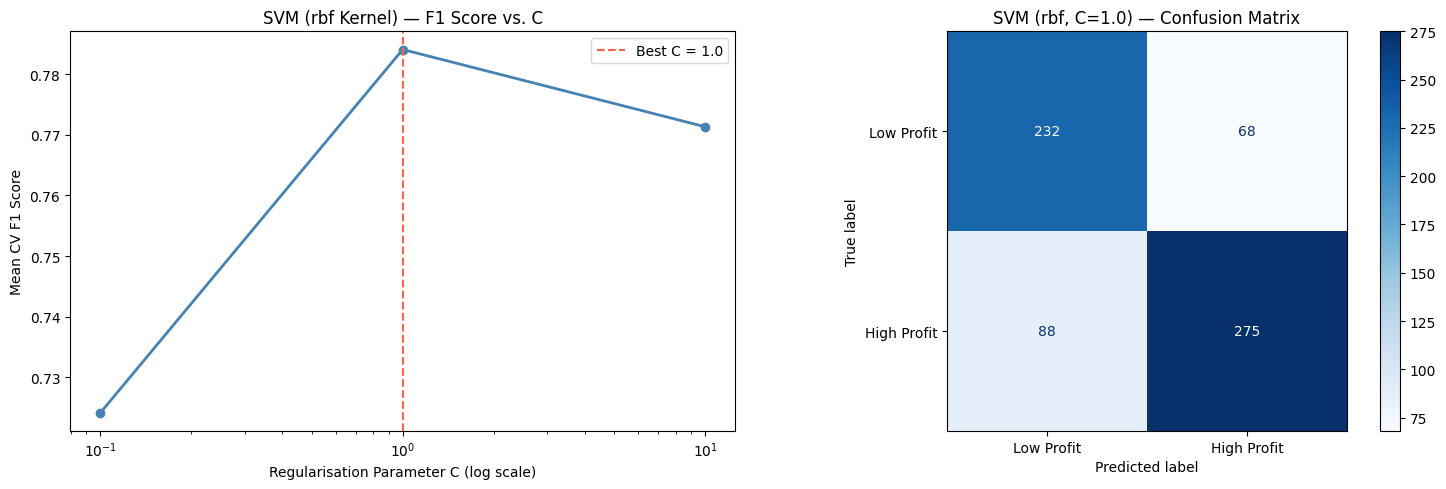


SVM Classification Report:
              precision    recall  f1-score   support

  Low Profit       0.72      0.77      0.75       300
 High Profit       0.80      0.76      0.78       363

    accuracy                           0.76       663
   macro avg       0.76      0.77      0.76       663
weighted avg       0.77      0.76      0.77       663



In [43]:
 # C vs Accuracy plot
c_values = [p['C'] for p in svm_cv.cv_results_['params']
            if p['kernel'] == svm_best.kernel]
cv_scores = [svm_cv.cv_results_['mean_test_score'][i]
             for i, p in enumerate(svm_cv.cv_results_['params'])
             if p['kernel'] == svm_best.kernel]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(c_values, cv_scores, marker='o', color='steelblue', linewidth=2)
axes[0].set_xscale('log')
axes[0].set_xlabel('Regularisation Parameter C (log scale)')
axes[0].set_ylabel('Mean CV F1 Score')
axes[0].set_title(f'SVM ({svm_best.kernel} Kernel) — F1 Score vs. C')
axes[0].axvline(svm_best.C, color='tomato', linestyle='--', label=f'Best C = {svm_best.C}')
axes[0].legend()

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test_clf, y_pred_svm),
    display_labels=['Low Profit', 'High Profit']
).plot(ax=axes[1], cmap='Blues', colorbar=True)
axes[1].set_title(f'SVM ({svm_best.kernel}, C={svm_best.C}) — Confusion Matrix')

plt.tight_layout()
plt.show()

print("\nSVM Classification Report:")
print(classification_report(y_test_clf, y_pred_svm,
                             target_names=['Low Profit', 'High Profit']))

##W5 Summary

The SVM with logistric regression performs better 78% than the RBF kernel and C = 1.0 at 76.5% accuracy.

# W6: Decision Tree and Random Forest


In [44]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# decision tree with tuned hyperparamters
dt_params = {'max_depth': [3, 5, 10, None], 'min_samples_leaf': [1, 5, 10]}
dt_cv = GridSearchCV(
    DecisionTreeClassifier(random_state=42), dt_params,
    cv=5, scoring='f1', n_jobs=-1
)
dt_cv.fit(X_train, y_train_clf)
dt_best = dt_cv.best_estimator_
print(f"Best DT params: {dt_cv.best_params_}")

y_pred_dt = dt_best.predict(X_test)
print(f"\nDecision Tree — Accuracy: {accuracy_score(y_test_clf, y_pred_dt):.4f}")
print(classification_report(y_test_clf, y_pred_dt, target_names=['Low Profit', 'High Profit']))

Best DT params: {'max_depth': 10, 'min_samples_leaf': 1}

Decision Tree — Accuracy: 0.8974
              precision    recall  f1-score   support

  Low Profit       0.87      0.91      0.89       300
 High Profit       0.92      0.89      0.90       363

    accuracy                           0.90       663
   macro avg       0.90      0.90      0.90       663
weighted avg       0.90      0.90      0.90       663



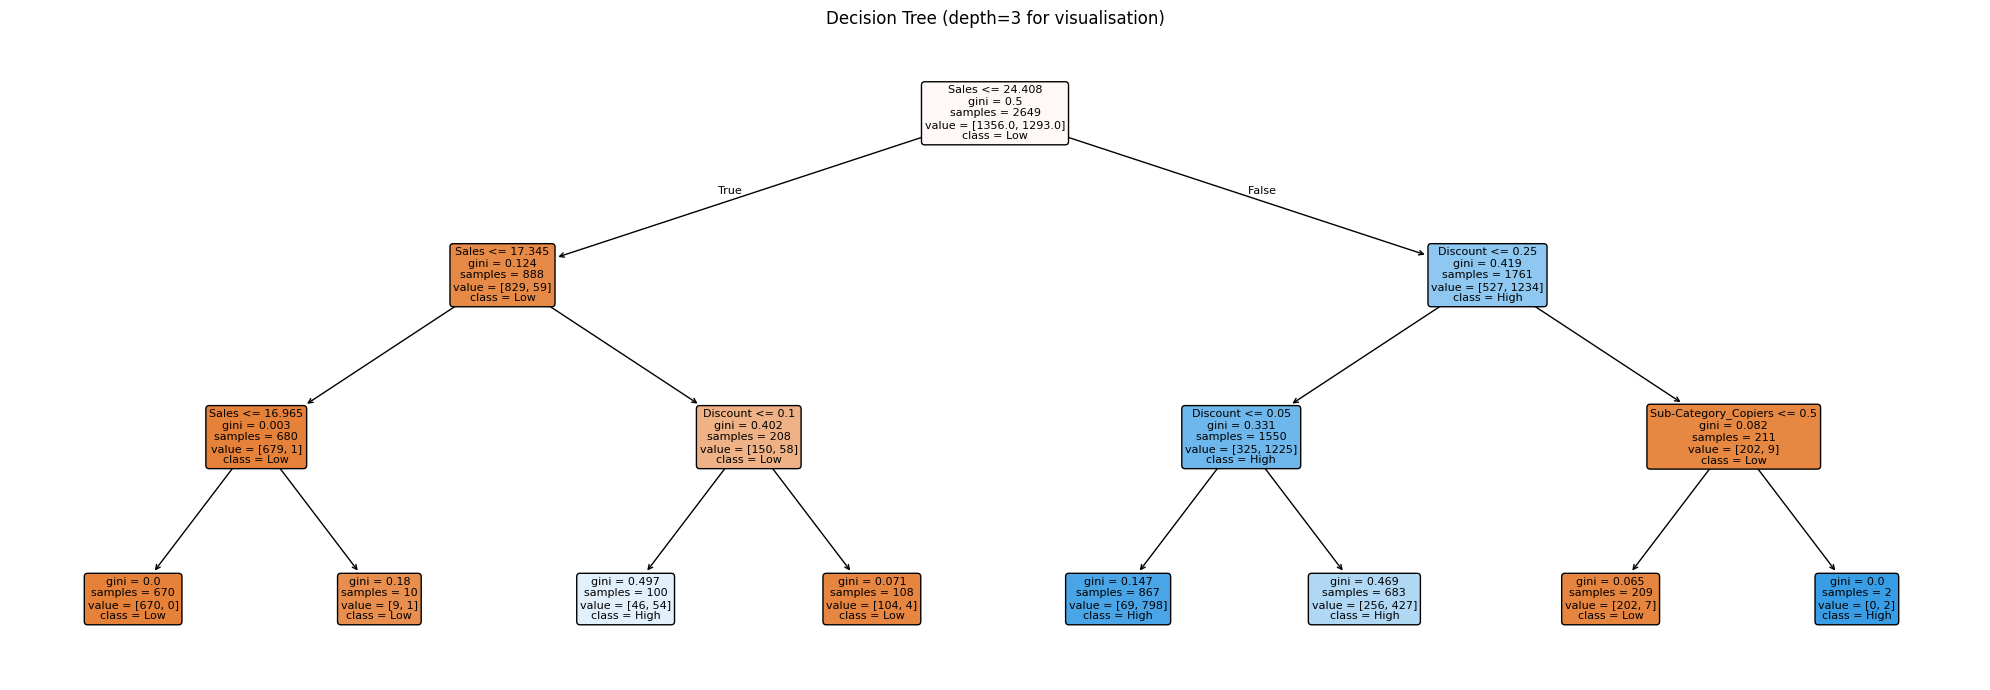

In [45]:
# Visualise the pruned tree
dt_vis = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_vis.fit(X_train, y_train_clf)

plt.figure(figsize=(20, 7))
plot_tree(dt_vis, feature_names=feature_cols,
          class_names=['Low', 'High'], filled=True,
          rounded=True, fontsize=8, max_depth=3)
plt.title('Decision Tree (depth=3 for visualisation)')
plt.tight_layout()
plt.show()

In [46]:
# Random forest with gridsearch
rf_params = {
    'n_estimators':   [100, 200],
    'max_depth':      [5, 10, 15, None],
    'min_samples_leaf': [1, 5]
}
rf_cv = GridSearchCV(
    RandomForestClassifier(random_state=42), rf_params,
    cv=5, scoring='f1', n_jobs=-1
)
rf_cv.fit(X_train, y_train_clf)
rf_best = rf_cv.best_estimator_
print(f"Best RF params: {rf_cv.best_params_}")

y_pred_rf = rf_best.predict(X_test)
print(f"\nRandom Forest — Accuracy: {accuracy_score(y_test_clf, y_pred_rf):.4f}")
print(classification_report(y_test_clf, y_pred_rf, target_names=['Low Profit', 'High Profit']))

Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}

Random Forest — Accuracy: 0.9005
              precision    recall  f1-score   support

  Low Profit       0.88      0.90      0.89       300
 High Profit       0.92      0.90      0.91       363

    accuracy                           0.90       663
   macro avg       0.90      0.90      0.90       663
weighted avg       0.90      0.90      0.90       663



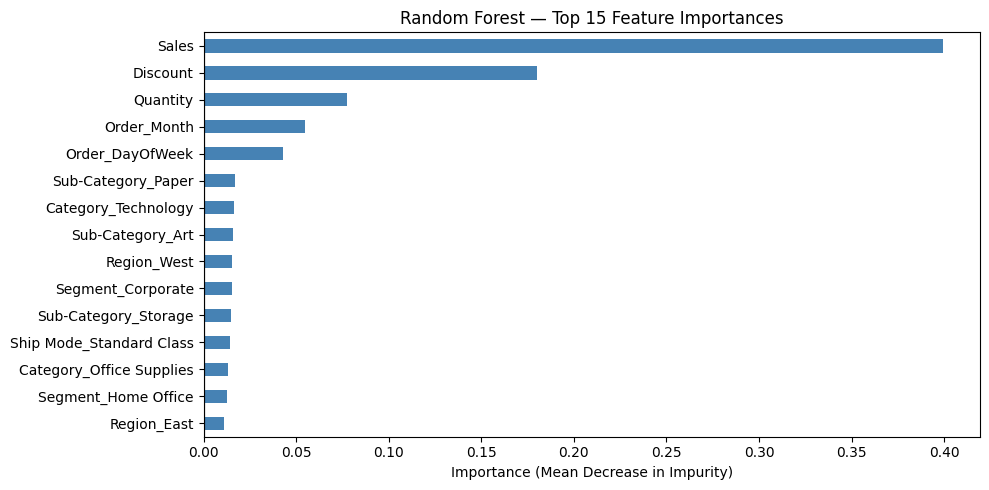

In [47]:
# Random Forest Feature Importance
fi = pd.Series(rf_best.feature_importances_, index=feature_cols)
fi_top = fi.nlargest(15)

plt.figure(figsize=(10, 5))
fi_top.sort_values().plot(kind='barh', color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Random Forest — Top 15 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

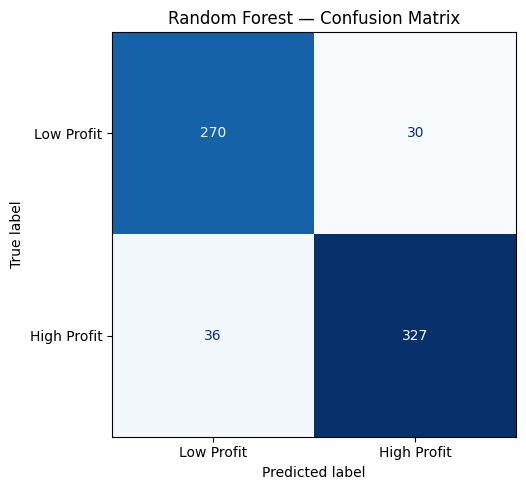

In [48]:
# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test_clf, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                 display_labels=['Low Profit', 'High Profit'])

fig, ax = plt.subplots(figsize=(6, 5))
disp_rf.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

# Model Comparison Summary

The table below consolidates performance metrics across all models trained in Weeks 1–6. Regression models are evaluated on R² and RMSE against `Profit_clipped`. Classification models are evaluated on Accuracy and F1-Score for `High_Profit`.

In [54]:
from sklearn.linear_model import LinearRegression

# Re-fit Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train_reg)

# Regression models — store (R², RMSE) tuples
regression_results = {
    'Linear Regression': (r2_score(y_test_reg, lr.predict(X_test)),
                          np.sqrt(mean_squared_error(y_test_reg, lr.predict(X_test)))),
    'Lasso':             (r2_score(y_test_reg, lasso_best.predict(X_test)),
                          np.sqrt(mean_squared_error(y_test_reg, lasso_best.predict(X_test)))),
    'Ridge':             (r2_score(y_test_reg, ridge_best.predict(X_test)),
                          np.sqrt(mean_squared_error(y_test_reg, ridge_best.predict(X_test)))),
    'ElasticNet':        (r2_score(y_test_reg, en_best.predict(X_test)),
                          np.sqrt(mean_squared_error(y_test_reg, en_best.predict(X_test)))),
    'PCR':               (r2_score(y_test_reg, pcr_preds),
                          np.sqrt(mean_squared_error(y_test_reg, pcr_preds))),
    'PLSR':              (r2_score(y_test_reg, plsr_preds),
                          np.sqrt(mean_squared_error(y_test_reg, plsr_preds))),
}

# Classification models
classification_results = {
    'Logistic Regression':                 accuracy_score(y_test_clf, y_pred_lr),
    f'SVM ({svm_best.kernel}, C={svm_best.C})':    accuracy_score(y_test_clf, y_pred_svm),
    f'Decision Tree (depth={dt_best.max_depth})': accuracy_score(y_test_clf, y_pred_dt),
    'Random Forest':                       accuracy_score(y_test_clf, y_pred_rf),
}

# ── Printed summary ───────────────────────────────────────
print("── Regression Models (R² / RMSE) ────────────────────────")
for name, (r2, rmse) in sorted(regression_results.items(), key=lambda x: -x[1][0]):
    print(f"  {name:25s}  R²: {r2:.4f}  RMSE: ${rmse:.2f}")

print()
print("── Classification Models (Accuracy) ─────────────────────")
for name, score in sorted(classification_results.items(), key=lambda x: -x[1]):
    print(f"  {name:40s}  Acc: {score:.4f}")


── Regression Models (R² / RMSE) ────────────────────────
  Lasso                      R²: 0.3916  RMSE: $91.00
  Linear Regression          R²: 0.3888  RMSE: $91.21
  PLSR                       R²: 0.3888  RMSE: $91.21
  Ridge                      R²: 0.3872  RMSE: $91.34
  ElasticNet                 R²: 0.3871  RMSE: $91.34
  PCR                        R²: 0.3206  RMSE: $96.17

── Classification Models (Accuracy) ─────────────────────
  Random Forest                             Acc: 0.9005
  Decision Tree (depth=10)                  Acc: 0.8974
  Logistic Regression                       Acc: 0.7798
  SVM (rbf, C=1.0)                          Acc: 0.7647


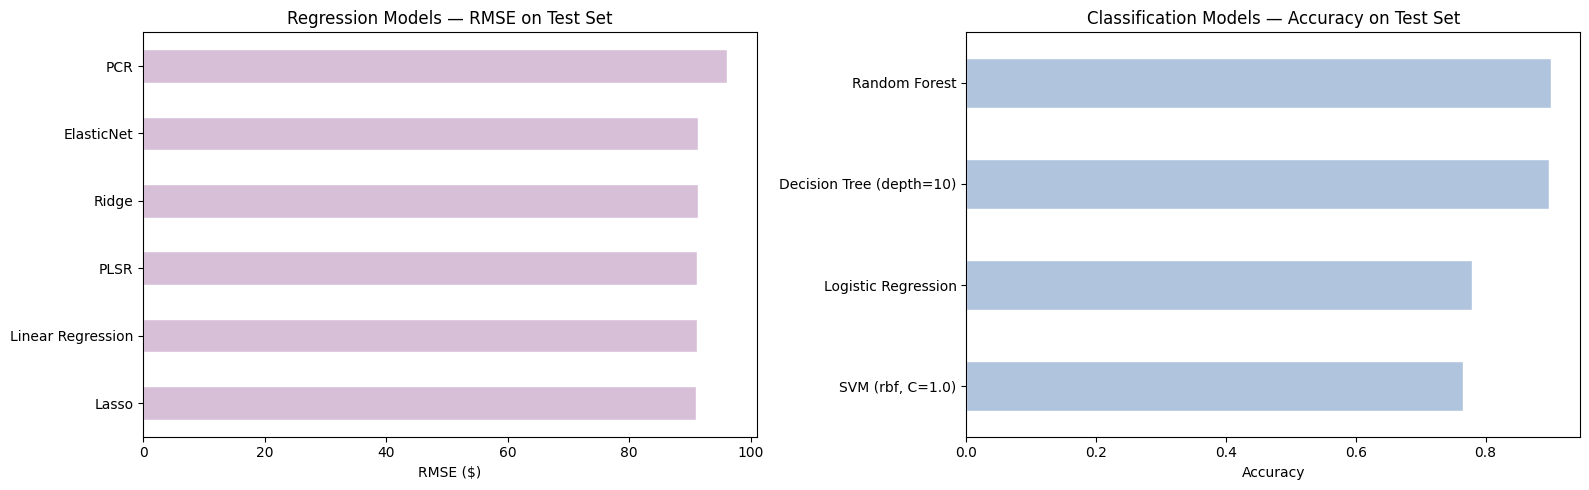

In [56]:
## Visual summary
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Regression RMSE
rmse_series = pd.Series({name: rmse for name, (r2, rmse) in regression_results.items()}).sort_values(ascending=True)
rmse_series.plot(kind='barh', ax=axes[0], color='thistle', edgecolor='white')
axes[0].set_title('Regression Models — RMSE on Test Set')
axes[0].set_xlabel('RMSE ($)')

# Classification accuracy
clf_df = pd.Series(classification_results).sort_values()
clf_df.plot(kind='barh', ax=axes[1], color='lightsteelblue', edgecolor='white')
axes[1].set_title('Classification Models — Accuracy on Test Set')
axes[1].set_xlabel('Accuracy')

plt.tight_layout()
plt.show()

#Overall Summary

Across all tested regression models, R^2 converges between 0.387 and 0.392. The dataset itself limits predictive power.

Classification on the other hand was more successful with Random Forest and Decision Tree both exceeding 90% accuracy, which outperformed Logistic regression (78%) and SVM (76.5%). This suggests that profit classification benefits from the non-linear interactions between these features.


###Key Takeaways
Profit is hard to predict precisely, but there are key categories that are shown to be more profitable than others based on various feature selection. Classification techniques work best on this dataset.

